In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [2]:
X,y=make_classification(n_samples=500,n_features=2,n_informative=2,
                       n_redundant=0,n_repeated=0,n_classes=2,
                        random_state=42,flip_y=0.01
                        )

In [3]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)


In [4]:
# Step 4: Use Grid Search to find the best value for k (from 1 to 10)
param_grid = {'n_neighbors': range(1, 11)}  # Try k from 1 to 10
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5)  # 5-fold cross-validation
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': range(1, 11)})

In [5]:
best_k=grid_search.best_params_['n_neighbors']
print(best_k)


3


In [6]:
knn_best=KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train,y_train)
y_pred=knn_best.predict(X_test)


In [7]:
accuracy=accuracy_score(y_pred,y_test)
print(accuracy)

0.96


In [8]:
k_values=range(1,11)
accuracies=[]
for k in k_values:
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,y_train)
    y_pred=knn.predict(X_test)
    accuracies.append(accuracy_score(y_pred,y_test))

    

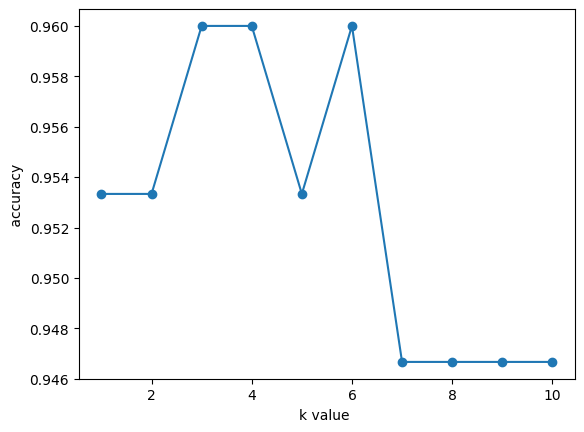

In [9]:
plt.Figure(figsize=(5,5))
plt.plot(k_values,accuracies,marker='o')
plt.xlabel("k value ")
plt.ylabel(" accuracy ")
plt.show()

svm 

linear  > staright line  ( linear)
polynomial  > curved data  ( poly )
RBF > complex non linear data (RBF)


In [10]:
from sklearn.svm import SVC
from sklearn.datasets import load_wine
import pandas as pd

In [11]:
wine=load_wine()
df=pd.DataFrame(data=wine.data,columns=wine.feature_names)
df['target']=wine.target
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [12]:
X=wine.data
y=wine.target

In [13]:
X=X[y!=2] #remove class 2
y=y[y!=2]
X=X[:,:2] #using only first 2 features 



In [14]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
svm_model=SVC(kernel='linear',random_state=42,C=2)
svm_model.fit(X_train,y_train)

SVC(C=2, kernel='linear', random_state=42)

In [16]:
y_pred=svm_model.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)

In [17]:
conf_matrix=confusion_matrix(y_test,y_pred)
print(y_test,y_pred)
class_report=classification_report(y_test,y_pred)
print(class_report)

[0 0 0 0 1 0 1 1 1 0 1 0 1 0 1 1 0 1 1 1 0 0 1 0 1 0] [0 0 0 0 1 0 1 1 1 0 1 0 1 0 1 1 0 1 1 1 0 0 1 0 1 0]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00        13

    accuracy                           1.00        26
   macro avg       1.00      1.00      1.00        26
weighted avg       1.00      1.00      1.00        26



linear  > staright line  ( linear)
polynomial  > curved data  ( poly )
RBF > complex non linear data (RBF)


In [18]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.svm import SVC 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_moons

In [19]:
X,y=make_moons(n_samples=300,noise=0.2,random_state=42)

In [20]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [21]:
model=SVC(kernel='rbf',C=3,gamma=1)
model.fit(X_train,y_train)

SVC(C=3, gamma=1)

In [22]:
y_predict=model.predict(X_test)

In [23]:
accuracy=accuracy_score(y_test,y_predict)
print(accuracy)

0.9888888888888889


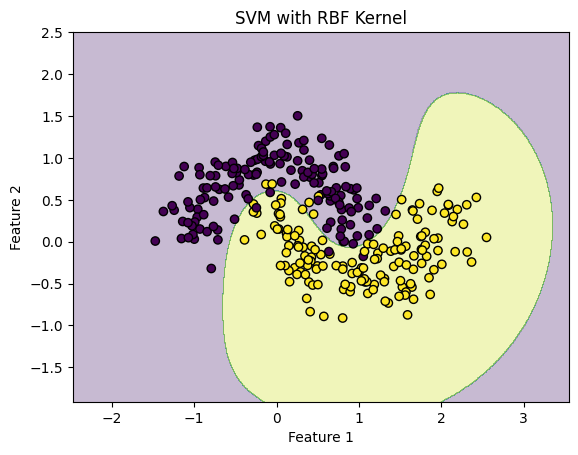

In [24]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1

y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(

    np.linspace(x_min, x_max, 500),

    np.linspace(y_min, y_max, 500)

)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

Z = Z.reshape(xx.shape)

# Plot contour

plt.contourf(xx, yy, Z, alpha=0.3)

# Plot dataset points

plt.scatter(

    X[:, 0],

    X[:, 1],

    c=y,

    edgecolors='k'

)

plt.title("SVM with RBF Kernel")

plt.xlabel("Feature 1")

plt.ylabel("Feature 2")

plt.show()

In [25]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.svm import SVC 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler


In [26]:
data=load_breast_cancer()


In [27]:
data=load_breast_cancer()
df=pd.DataFrame(data=data.data,columns=data.feature_names)
df['target']=data.target
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [28]:
X=data.data
y=data.target

In [29]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [30]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [31]:
svm_model=SVC(kernel='rbf',C=3,gamma=1)
svm_model.fit(X_train,y_train)

SVC(C=3, gamma=1)

In [32]:
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train,y_train)

KNeighborsClassifier()

In [33]:
svm_pred=svm_model.predict(X_test)
knn_pred=knn_model.predict(X_test)

In [34]:
svm_accuracy=accuracy_score(y_test,svm_pred)
knn_accuracy=accuracy_score(y_test,knn_pred)

In [35]:
print(f'svm accuracy :::{svm_accuracy}')
print(f'knn accuracy:::{knn_accuracy}')

svm accuracy :::0.6374269005847953
knn accuracy:::0.9590643274853801


test case 

In [36]:
sample=X_test[1].reshape(1,-1)  

svm_result=svm_model.predict(sample)
knn_result=knn_model.predict(sample)

classes=data.target_names


print(classes[y_test[1]])
print(f'svm predict :::{classes[svm_result[0]]}')
print(f'knn predict:::{classes[knn_result[0]]}')

malignant
svm predict :::benign
knn predict:::malignant
